In [ ]:
# !pip install torch --index-url https://download.pytorch.org/whl/cu118
!pip install ivon-opt
!pip install torch==2.1.0 torchvision==0.16.0
!pip install ivon

ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1)
ERROR: No matching distribution found for torch==2.1.0
ERROR: Could not find a version that satisfies the requirement ivon (from versions: none)
ERROR: No matching distribution found for ivon


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import ivon
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import sys
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
from torch.optim.lr_scheduler import LinearLR
from torch.utils.data import Subset

In [ ]:
# --- Standard CIFAR-10 normalization ---
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# --- Load CIFAR-10 train data (will later be split into train and val) ---
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform_train,   # training transform (with augmentation)
    download=True
)

# --- Create a validation dataset that uses NO augmentation ---
full_val_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform_test,    # no augmentation for validation
    download=True
)

# --- Train/Val split ---
train_ratio = 0.9          # e.g., 90% train, 10% validation
n_train = int(len(full_train_dataset) * train_ratio)
n_val = len(full_train_dataset) - n_train

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

# Replace validation transform
val_dataset.dataset = full_val_dataset

# --- Load CIFAR-10 test data ---
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform_test,
    download=True
)

# --- DataLoaders (batch_size = 50 to match IVON paper) ---
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=50, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=50, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNet20(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super().__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        # Dropout
        self.dropout = nn.Dropout(p=dropout_prob)
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, 10)

    def _make_layer(self, planes, blocks, stride):
        strides = [stride] + [1]*(blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        #out = self.dropout(out)         #  Dropout la jag till här
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def variance_batch(x, model, ivon, n_classes) -> torch.Tensor:
    sub_results = []
    for i in range(x.size(0)):
        sub_results.append(variance(x_vector=x[i], model=model, ivon_optimizer=ivon, numb_classes=n_classes))
    return torch.stack(sub_results, dim=0)

def variance(x_vector, model, ivon_optimizer, numb_classes):
  jacobian = torch.zeros(0, numb_classes, dtype=x_vector.dtype, device=x_vector.device)
  sigma2 = torch.zeros(0, dtype=x_vector.dtype, device=x_vector.device)
  # Loop through all parameters to fill the jacobian and sigma buffers
  for group in ivon_optimizer.param_groups:
    for param in group['params']:
      this_param_jacobian_shape = (param.numel(), numb_classes)
      jacobian = torch.cat((jacobian, torch.zeros(this_param_jacobian_shape, dtype=x_vector.dtype, device=x_vector.device)), dim=0)

    this_sigma2 = 1.0 / group["ess"] * (group["hess"] + group["weight_decay"])
    sigma2 = torch.cat((sigma2, this_sigma2))

  n_parameters = jacobian.shape[0]

  for i in range(numb_classes):
    output = model(x_vector[None, ...])
    metric = output.squeeze(0)[i]
    ivon_optimizer.zero_grad()
    metric.backward()

    param_i = 0
    for param in model.parameters():
      assert param.grad is not None
      flattened_grad = param.grad.flatten()
      jacobian[param_i:param_i + flattened_grad.numel(), i] = flattened_grad
      param_i += flattened_grad.numel()

  V = torch.einsum("pc,p,pd", jacobian, sigma2, jacobian)
  return V

def error(X, y, model_ivon, optimizer_ivon, numb_classes):
  logits = model_ivon(X)
  probs = nn.functional.softmax(logits, dim=1)
  error = probs - nn.functional.one_hot(y, num_classes=numb_classes)
  return error

def evaluate(train_loader, model_ivon, optimizer_ivon, numb_classes,
             subsample_size=1000, subsample_seed=42):
  model_ivon.eval()

  # 1. Standard test loss (on test set)
  total_test_loss = 0.0
  for X, y in test_loader:
      X = X.to(device)
      y = y.to(device)
      logits = model_ivon(X)
      total_test_loss += F.cross_entropy(logits, y, reduction="sum").item()

  test_loss = total_test_loss / len(test_loader.dataset)


  # Skapa subsample av träningsdata
  train_dataset = train_loader.dataset
  total_train_size = len(train_dataset)
  actual_subsample_size = min(subsample_size, total_train_size)

  np.random.seed(subsample_seed)
  subsample_indices = np.random.choice(total_train_size, actual_subsample_size, replace=False)
  subsample_dataset = Subset(train_dataset, subsample_indices)
  subsample_loader = torch.utils.data.DataLoader(
      subsample_dataset,
      batch_size=train_loader.batch_size,
      shuffle=False
  )

  total_loo_loss = 0.0
  for X, y in subsample_loader:
      X, y = X.to(device), y.to(device)
      var = variance_batch(X, model_ivon, optimizer_ivon, numb_classes)
      error_loo = error(X, y, model_ivon, optimizer_ivon, numb_classes)
      #print(error_loo)

      # Beräkna sensitivity: v_i * e_i = V @ e för varje sample
      sensitivity = var @ error_loo[:, :, None]  # [batch, n_classes, 1]
      sensitivity = sensitivity.squeeze(-1)  # [batch, n_classes]

      # Beräkna LOO predictions: f_i + v_i * e_i
      logits = model_ivon(X)  # [batch, n_classes]
      f_loo = logits + sensitivity  # [batch, n_classes] + [batch, n_classes] = [batch, n_classes] ✓

      # Beräkna LOO loss: ℓ(f_i + v_i * e_i)
      loo_loss_per_sample = F.cross_entropy(f_loo, y, reduction='none')  # [batch]

      total_loo_loss += loo_loss_per_sample.sum().item()  # Summa över batchen

  # Beräkna genomsnittlig LOO loss över hela train set
  loo_loss = total_loo_loss / actual_subsample_size #len(train_loader.dataset)

  return test_loss, loo_loss


model_ivon = ResNet20().to(device)
optimizer_ivon = ivon.IVON(model_ivon.parameters(), lr=0.1, ess=len(train_dataset))


for epoch in range(20):
  model_ivon.train()
  for X, y in train_loader:
      X, y = X.to(device), y.to(device)
      optimizer_ivon.zero_grad()
      for _ in range(1): #numb train samples
          with optimizer_ivon.sampled_params(train=True):
              logits = model_ivon(X)
              loss = F.cross_entropy(logits, y)
              loss.backward()
      optimizer_ivon.step()

  test_loss, loo_loss = evaluate(train_loader, model_ivon, optimizer_ivon,logits.shape[1])
  print(f"Test loss: {test_loss:.4f}, LOO loss: {loo_loss:.4f}")




KeyboardInterrupt: 

IVON test and LOO loss:

Test loss: 1.6309, LOO loss: 1.6213
Test loss: 1.0832, LOO loss: 1.0994
Test loss: 1.1308, LOO loss: 1.1585
Test loss: 0.7452, LOO loss: 0.7308
Test loss: 0.6431, LOO loss: 0.6059
Test loss: 0.7445, LOO loss: 0.7282
Test loss: 0.6045, LOO loss: 0.5776
Test loss: 0.6064, LOO loss: 0.5528
Test loss: 0.5862, LOO loss: 0.5796
Test loss: 0.5831, LOO loss: 0.5593
Test loss: 0.6144, LOO loss: 0.5683
Test loss: 0.5591, LOO loss: 0.4868
Test loss: 0.5020, LOO loss: 0.4237
Test loss: 0.4752, LOO loss: 0.4174
Test loss: 0.4927, LOO loss: 0.4173
Test loss: 0.4835, LOO loss: 0.4084
Test loss: 0.4577, LOO loss: 0.3407
Test loss: 0.5146, LOO loss: 0.4128
Test loss: 0.4578, LOO loss: 0.3571
Test loss: 0.4563, LOO loss: 0.3674

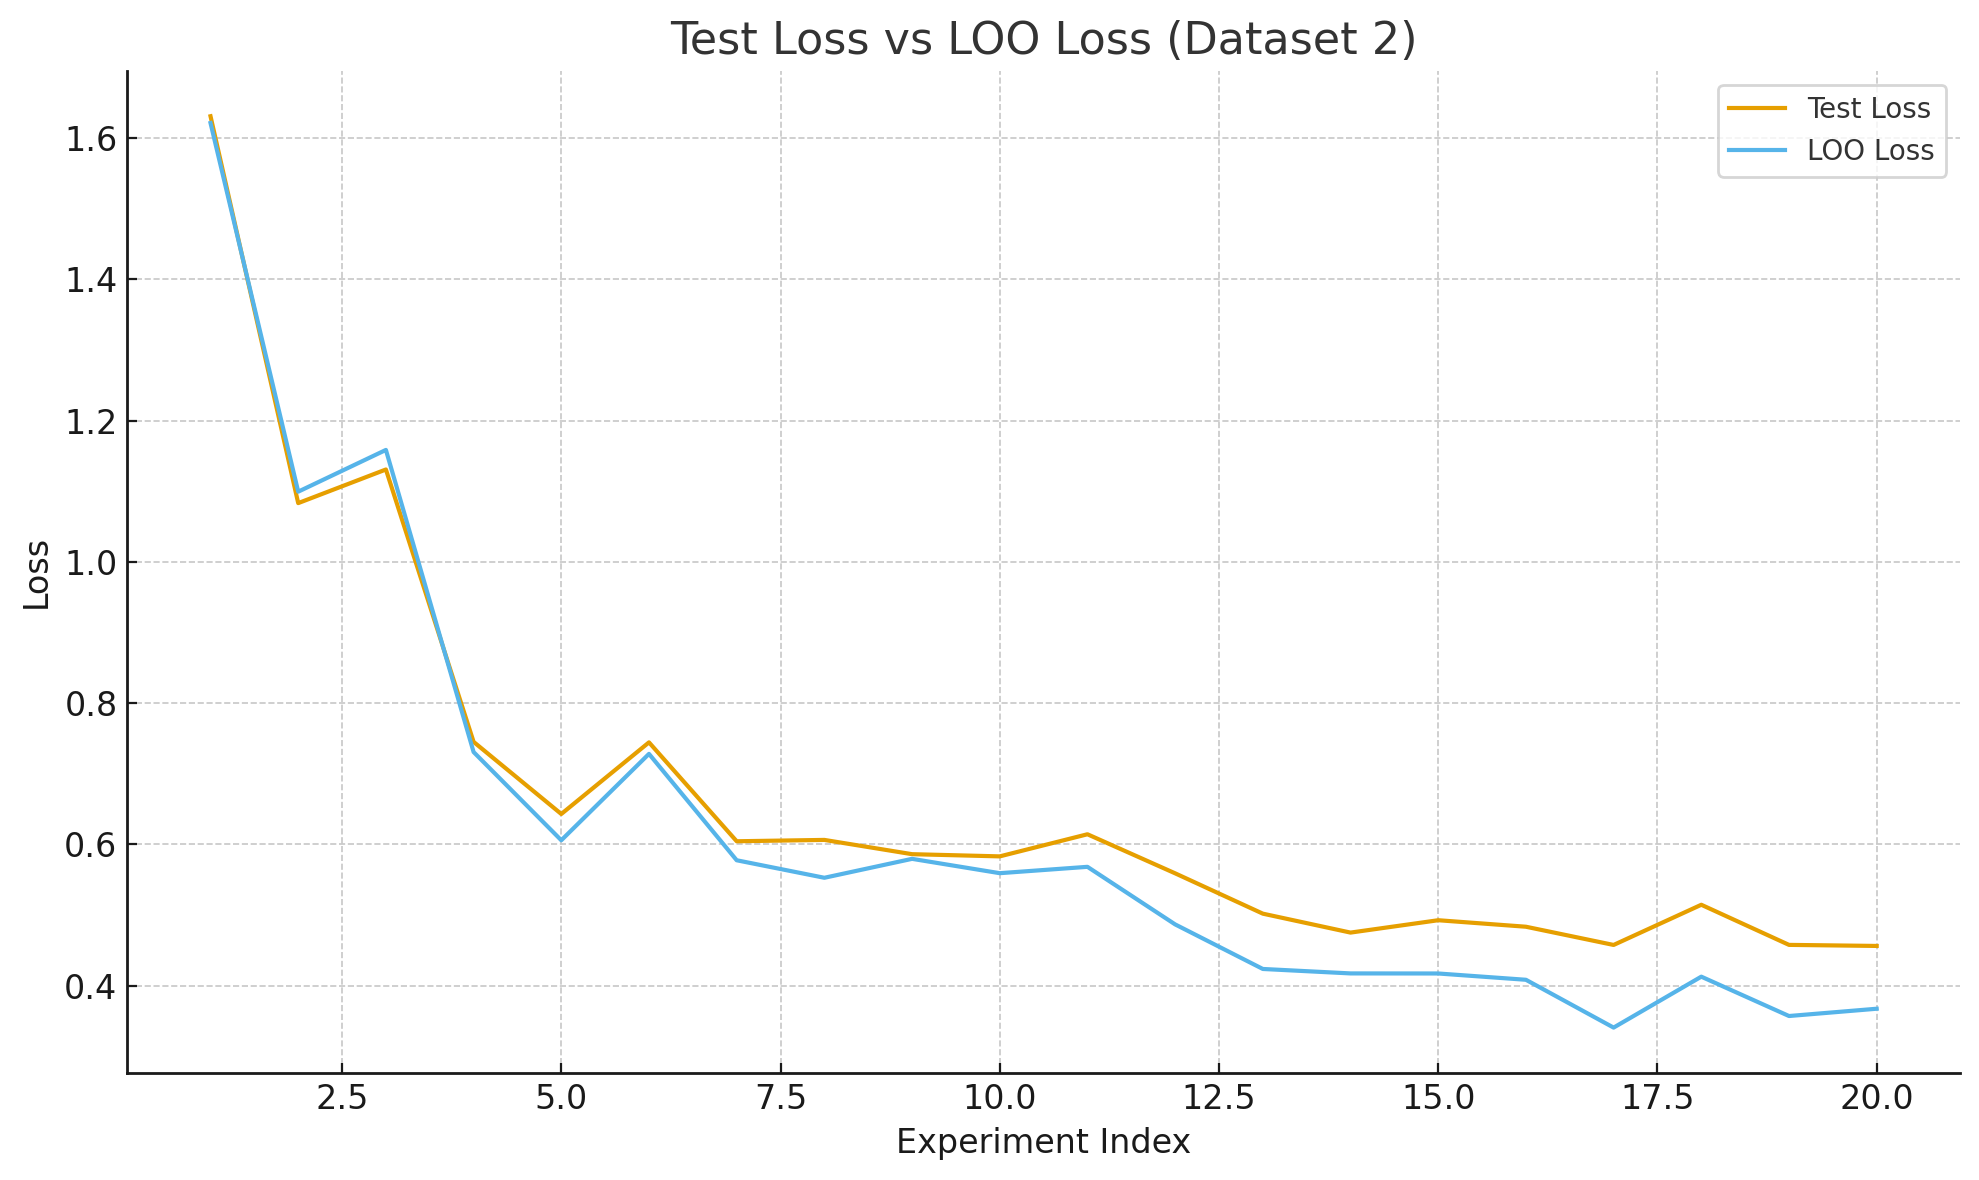